<a href="https://colab.research.google.com/github/ancestor9/2026_Spring_Application_Developments/blob/main/week11/decison_trre_ensemble_boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tree based classification 이해 및 실습**

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
import warnings
warnings.filterwarnings(action='ignore')

# <font color='orange'> A. 머신러닝 학습 프로세스

## 1. 목적정의
### 정확도(Accuracy)를 평가지표로 예측 모형 선정

## 2. 자료 정제 분석
### 자료 확보

In [2]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

# 3. 특성변수
## 부적합에 영향을 미치는 변수 선정
### 'worst smoothness', 'worst perimeter' 2개의 특성변수로  'target'을 예측

In [3]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
df = X.merge(y, left_index=True, right_index=True)
df.target.value_counts()
df.target.value_counts(normalize=True)
df.target = df.target.replace({0:1, 1:0})
data =df[['worst smoothness', 'worst perimeter', 'target']]
data

,count
target,
1,357
0,212


,proportion
target,
1,0.627417
0,0.372583


,worst smoothness,worst perimeter,target
0,0.16220,184.60,1
1,0.12380,158.80,1
2,0.14440,152.50,1
3,0.20980,98.87,1
4,0.13740,152.20,1
...,...,...,...
564,0.14100,166.10,1
565,0.11660,155.00,1
566,0.11390,126.70,1
567,0.16500,184.60,1


# 4. 모형 평가
## 모형의 정확도를 기준(Accuracy)

In [4]:
from sklearn.preprocessing import StandardScaler

data =df[['worst smoothness', 'worst perimeter', 'target']]
X = data.drop('target', axis=1)
#scaler = StandardScaler()
#data.loc[:, 'worst smoothness' : 'worst perimeter'] = scaler.fit_transform(X)

X = data.drop('target', axis=1)
y = data['target']

# <font color='orange'> B. Decision Tree 알고리즘
## 1. 데이터 확보(50개의 sample 데이터)

,count
target,
0,34
1,16


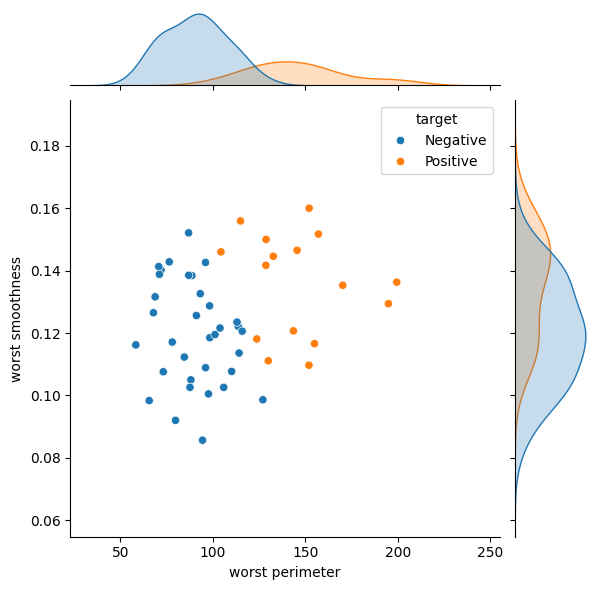

In [5]:
import seaborn as sns
data = data.sample(50, random_state= 1024)
data.target.value_counts()
data.target = data.target.replace({0: 'Negative', 1: 'Positive'})
sns.jointplot(data=data, y='worst smoothness', x='worst perimeter', hue='target')

## 2. Pruning methods
## Level 1 - Stump

DecisionTreeClassifier(max_depth=1, random_state=11)

<Figure size 800x600 with 0 Axes>

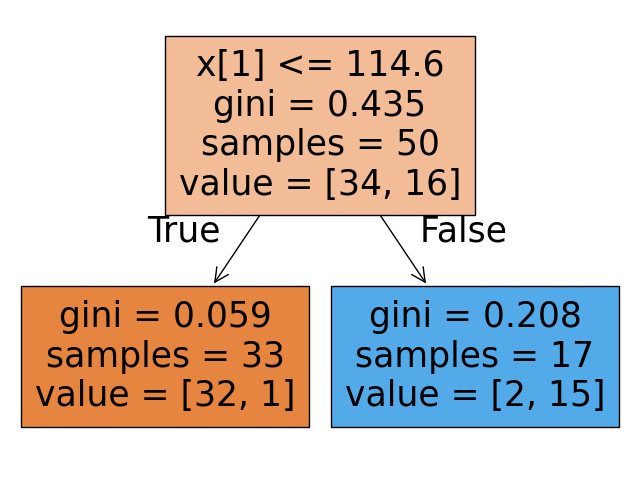

In [6]:
from sklearn.tree import plot_tree, DecisionTreeClassifier
import matplotlib.pyplot as plt

X = data.drop('target', axis=1)
y = data.target

dt = DecisionTreeClassifier(max_depth=1, random_state=11)
dt.fit(X, y)

plt.figure(figsize=(8,6))
ax = plot_tree(dt, filled=True)

## Level 2

DecisionTreeClassifier(max_depth=2, random_state=11)

<Figure size 1000x800 with 0 Axes>

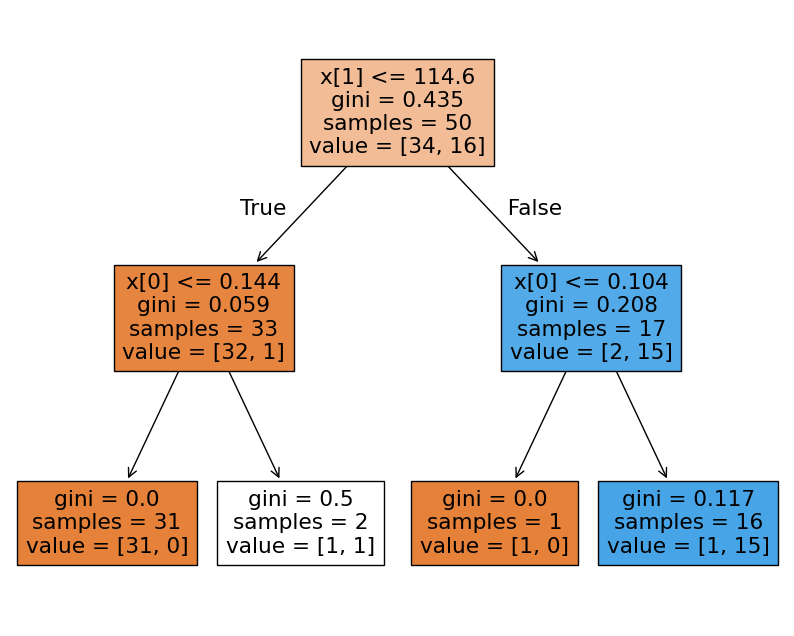

In [7]:
dt = DecisionTreeClassifier(max_depth=2, random_state=11)

dt.fit(X, y)
plt.figure(figsize=(10,8))

ax = plot_tree(dt, filled=True)

## Level 4 - Overfitting

DecisionTreeClassifier(random_state=11)

<Figure size 800x600 with 0 Axes>

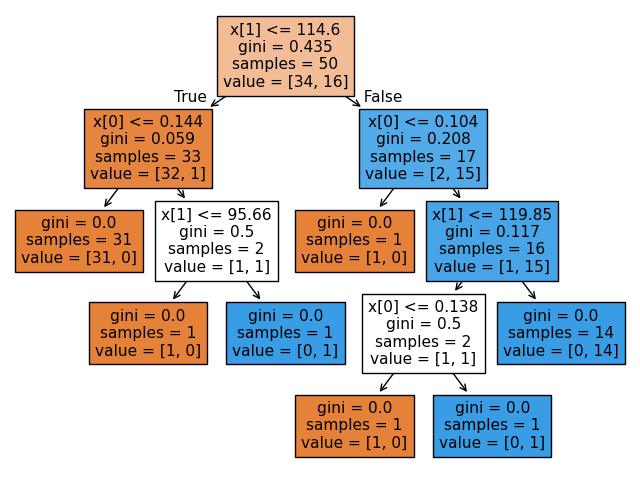

In [8]:
X = data.drop('target', axis=1); y = data['target']

dt = DecisionTreeClassifier(random_state=11)
dt.fit(X, y)

plt.figure(figsize=(8,6))
ax = plot_tree(dt, filled=True)

## Nicolas de Condorcet’s Jury Theorm

<Figure size 2000x800 with 0 Axes>

Text(0.5, 0, 'trilas')

Text(0, 0.5, 'The jury verdict.')

(array([-200.,    0.,  200.,  400.,  600.,  800., 1000., 1200.]),
 [Text(-200.0, 0, '−200'),
  Text(0.0, 0, '0'),
  Text(200.0, 0, '200'),
  Text(400.0, 0, '400'),
  Text(600.0, 0, '600'),
  Text(800.0, 0, '800'),
  Text(1000.0, 0, '1000'),
  Text(1200.0, 0, '1200')])

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, -0.2, '−0.2'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4000000000000001, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0000000000000002, '1.0'),
  Text(0, 1.2000000000000002, '1.2')])

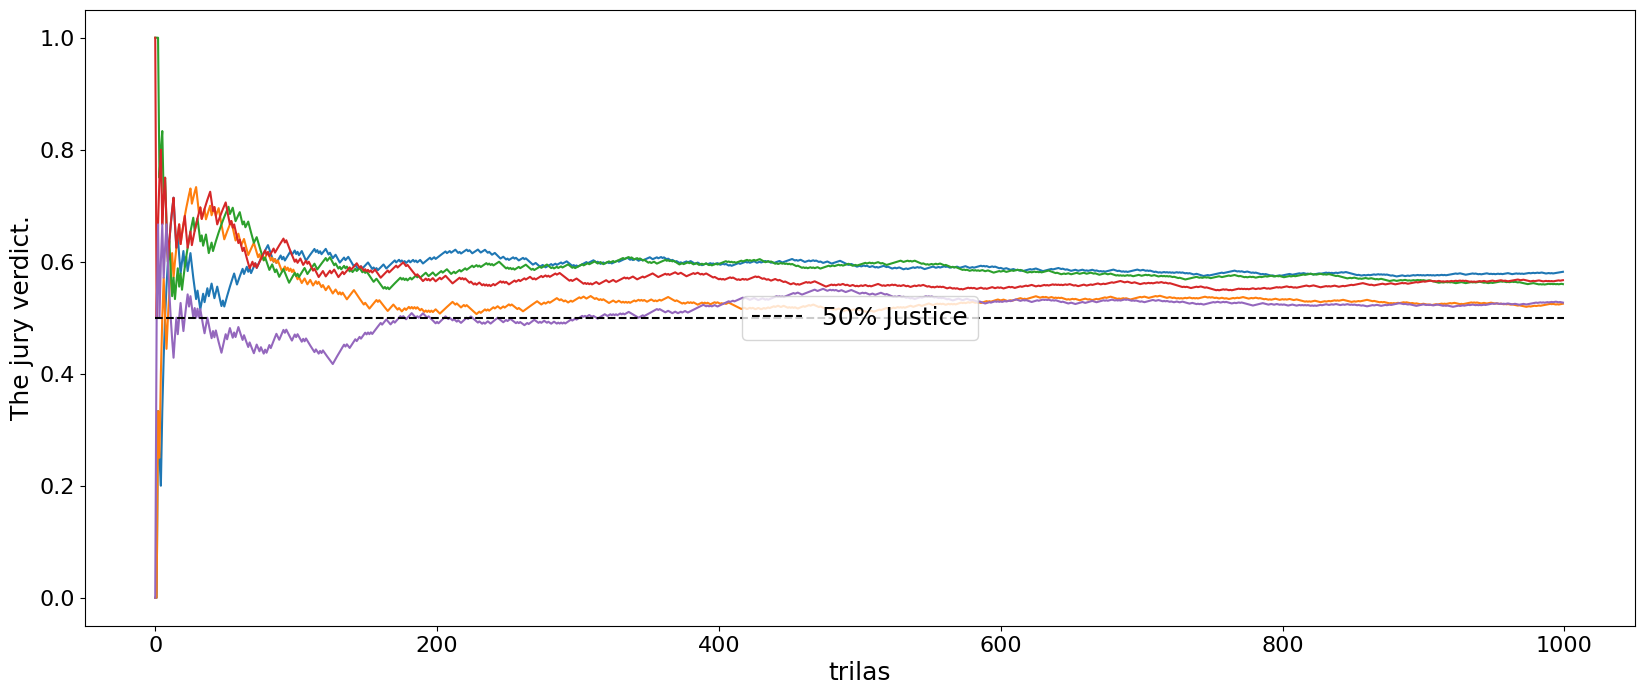

In [9]:
import numpy as np
jurors_proba = 0.55 ; num_jurors = 5; num_trals = 1000
num_decisions=(np.random.rand(num_trals, num_jurors)<jurors_proba)*1
total_trials = np.arange(1, num_trals+1).reshape(-1, 1)
cum_right_ratio=np.cumsum(num_decisions, axis=0)/total_trials
plt.figure(figsize=(20,8)); plt.plot(cum_right_ratio)
plt.plot([0, num_trals], [0.5, 0.5], 'k--', label='50% Justice')

plt.xlabel('trilas', fontsize= '18'); plt.ylabel('The jury verdict.', fontsize= '18')
plt.xticks(fontsize= '16');plt.yticks(fontsize= '16')

plt.legend(fontsize=18, loc='center')

# <font color='orange'> C. 앙상블 모형(Ensemble)
## 전체 데이터 확보(모든 변수 사용)
    
## 1. Decision Tree 모형

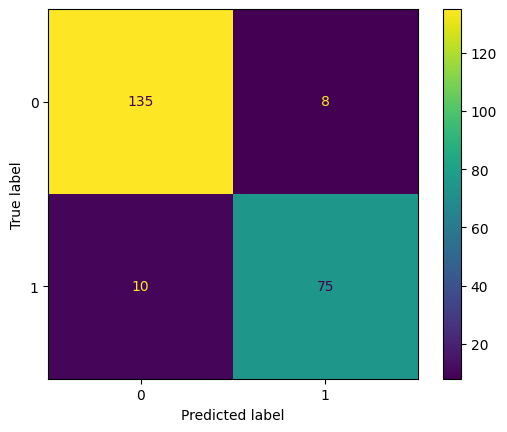

              precision    recall  f1-score   support

           0       0.93      0.94      0.94       143
           1       0.90      0.88      0.89        85

    accuracy                           0.92       228
   macro avg       0.92      0.91      0.92       228
weighted avg       0.92      0.92      0.92       228



In [10]:
from sklearn.model_selection import train_test_split
X = df.drop('target', axis=1); y = df['target']
X_train, X_test, y_train, y_test=train_test_split(X, y,
                                                  test_size=0.4,
                                                  stratify= y, random_state=11)

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

dt = DecisionTreeClassifier(random_state=11)
y_predict = dt.fit(X_train, y_train).predict(X_test)

ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test); plt.show()
print(classification_report(y_test, y_predict))

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 11,
 'splitter': 'best'}

<Figure size 800x600 with 0 Axes>

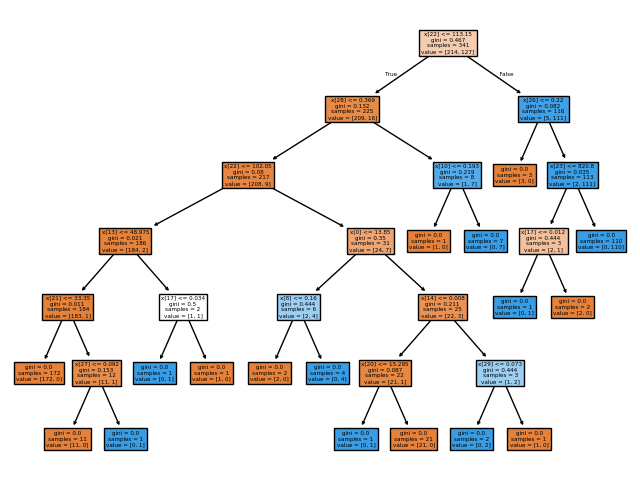

In [11]:
dt.get_params()
plt.figure(figsize=(8,6))
ax = plot_tree(dt, filled=True)

## 2. Bagging 모형

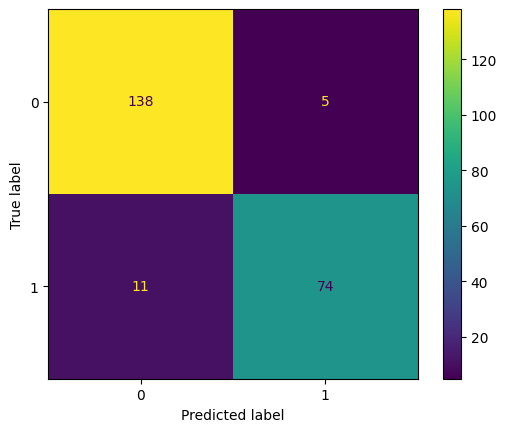

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       143
           1       0.94      0.87      0.90        85

    accuracy                           0.93       228
   macro avg       0.93      0.92      0.92       228
weighted avg       0.93      0.93      0.93       228



In [12]:
import numpy as np
np.random.seed(1357)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import ensemble

bag = ensemble.BaggingClassifier(dt, n_estimators = 30, max_samples =0.8)
y_predict = bag.fit(X_train, y_train).predict(X_test)
ConfusionMatrixDisplay.from_estimator(bag, X_test, y_test); plt.show()
print(classification_report(y_test, y_predict))

## 3. Random forest 모형

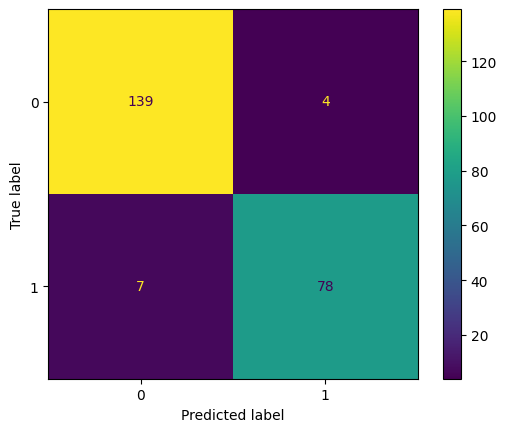

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       143
           1       0.95      0.92      0.93        85

    accuracy                           0.95       228
   macro avg       0.95      0.94      0.95       228
weighted avg       0.95      0.95      0.95       228



In [13]:
import numpy as np
np.random.seed(4321)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay # Added import for ConfusionMatrixDisplay
rf = ensemble.RandomForestClassifier(random_state=11)
y_predict = rf.fit(X_train, y_train).predict(X_test)

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test); plt.show() # Changed to ConfusionMatrixDisplay
print(classification_report(y_test, y_predict))

시뮬레이션 평균 정확도  0.9488199999999998


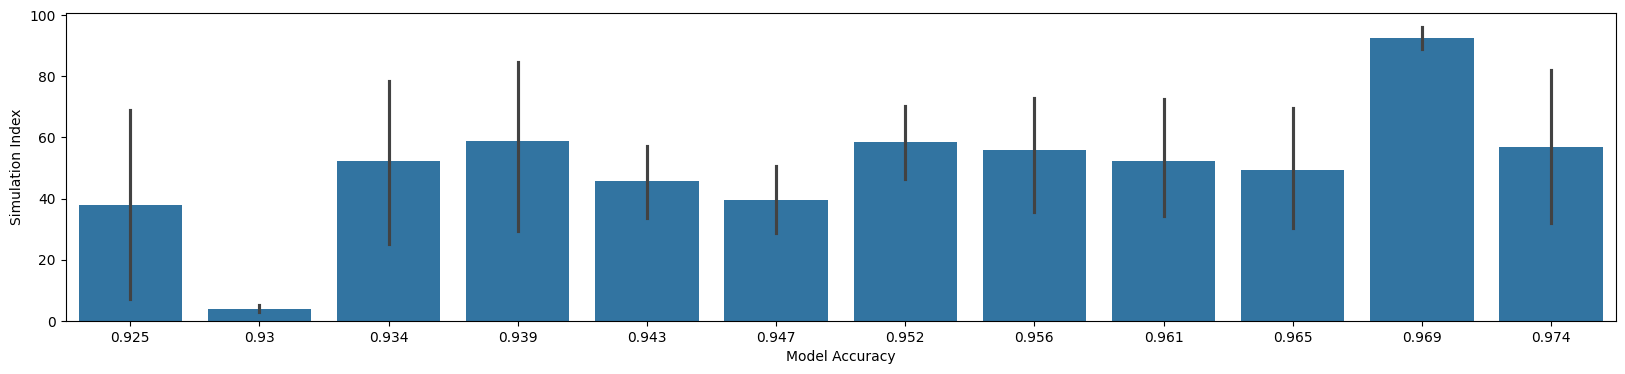

In [14]:
import pandas as pd
from sklearn import metrics

acc_list = []
recall_list = []

for i in np.random.choice(2500, 100, replace=False) :
    clf = ensemble.RandomForestClassifier(n_estimators = 10, random_state = i)
    preds =  clf.fit(X_train, y_train).predict(X_test)
    acc = round(metrics.accuracy_score(y_true = y_test, y_pred = preds), 3)
    recall = metrics.recall_score(y_true = y_test, y_pred = preds, average='macro')

    acc_list.append(acc)
    recall_list.append(recall)

data = (pd.Series(acc_list).reset_index().
        rename(columns={'index': 'Simulation Index', 0: 'Model Accuracy'}))
print('시뮬레이션 평균 정확도 ', data['Model Accuracy'].mean())

fig, ax = plt.subplots()
fig.set_size_inches(20, 4)
ax = sns.barplot(x='Model Accuracy', y='Simulation Index', data=data)

## 4. Extra 의사결정 모형

In [16]:
y_proba = rf.predict_proba(X_test)

In [17]:
print(f'정확도(accuracy): {metrics.accuracy_score(y_test, y_predict)}')
print(f'AUROC: {metrics.roc_auc_score(y_test, y_proba[:, 1])}')
print(f'AP: {metrics.average_precision_score(y_test, y_proba[:, 1])}')

정확도(accuracy): 0.9517543859649122
AUROC: 0.9950226244343892
AP: 0.9916048226041331


In [18]:
def to_labels(pos_probs, threshold):
    return (pos_probs >= threshold).astype('int')

p, r, thresholds = metrics.precision_recall_curve(y_test, y_proba[:, 1])
scores = [np.sum(to_labels(y_proba[:, 1], t))/len(y_proba[:, 1]) for t in thresholds]

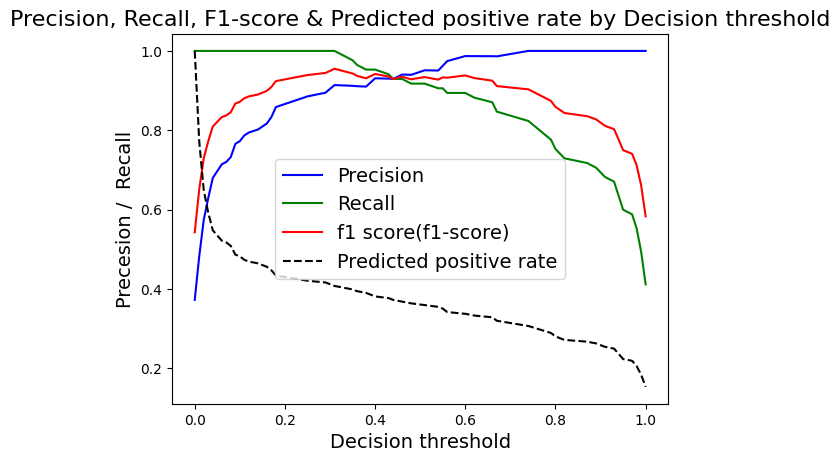

In [19]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.title('Precision, Recall, F1-score & Predicted positive rate by Decision threshold', fontsize='16')
    plt.plot(thresholds, precisions[:-1], 'b-', label='Precision') # 판사
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall') # 검사
    plt.plot(thresholds, (2*precisions[:-1]*recalls[:-1])/(precisions[:-1] +recalls[:-1]),
             'r-', label='f1 score(f1-score)') # 변호사
    plt.plot(thresholds, scores, 'k--', label='Predicted positive rate') # q-ratio
    plt.ylabel('Precesion /  Recall', fontsize='14')
    plt.xlabel('Decision threshold', fontsize='14')
    plt.legend(loc='best', fontsize='14')

    plt.show()

plot_precision_recall_vs_threshold(p, r, thresholds)

# End

## Classifier comparison
- https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

In [20]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

Text(0.5, 1.0, 'Input data')

(-1.818500344394381, 2.6813716830490253)

(-1.5357020680498332, 2.071899312714103)

[]

[]

...

(-2.301737447070235, 3.6087431161656847)

(0.06802498168359294, 4.392677587182645)

[]

[]

Text(3.308743116165685, 0.36802498168359293, '.95')

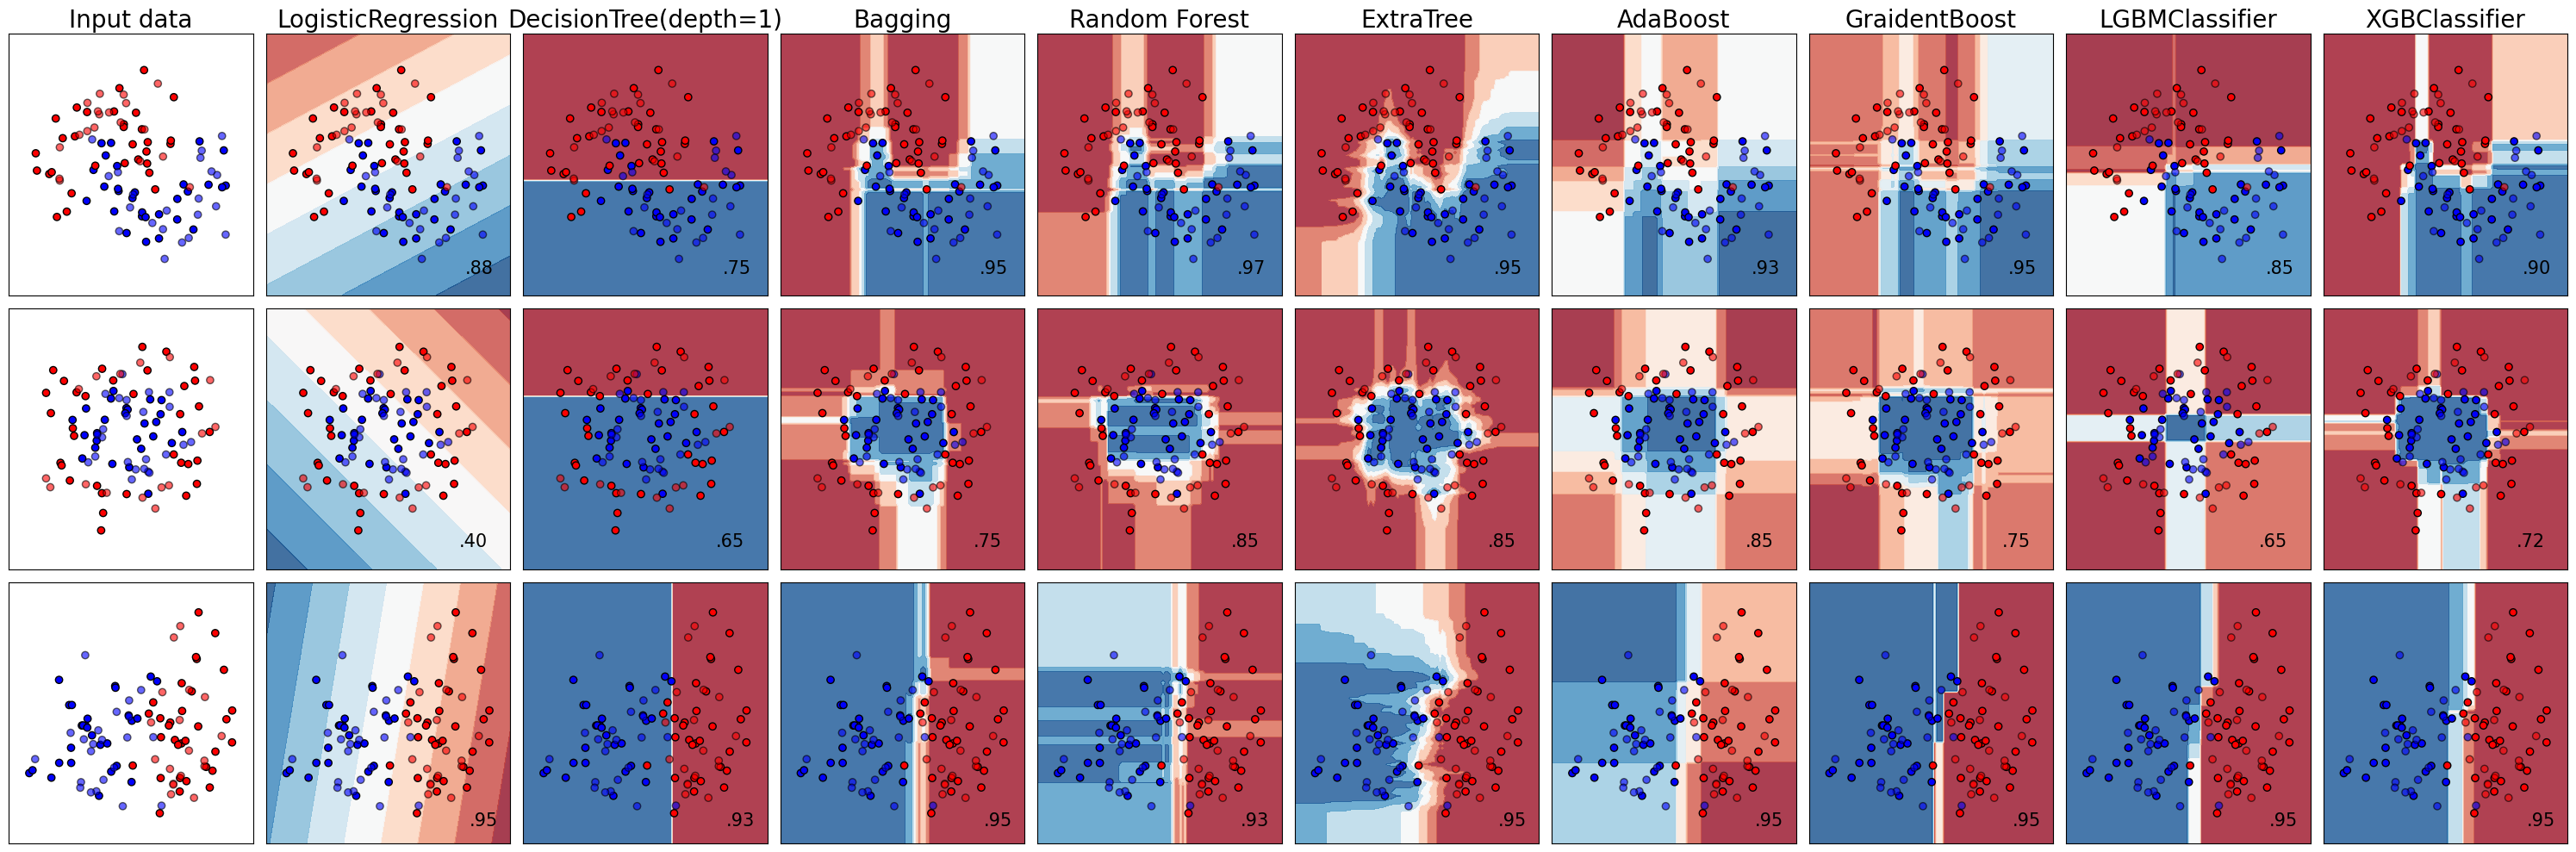

In [21]:
# Code source: Gaël Varoquaux
#              Andreas Müller
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn import ensemble
from sklearn.linear_model import LogisticRegression # Added import
from lightgbm import LGBMClassifier # Added import
from xgboost import XGBClassifier # Added import

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay

names = [
    #"Decision Tree(depth=1)", "Decision Tree(depth=2)", "Decision Tree(depth=3)", "Decision Tree(depth=5)",
    "LogisticRegression",
    "DecisionTree(depth=1)",
    "Bagging",
    "Random Forest",
    "ExtraTree",
    "AdaBoost",
    "GraidentBoost",
    "LGBMClassifier",
    "XGBClassifier"
]

classifiers = [
    #DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3),
    LogisticRegression(),
    DecisionTreeClassifier(max_depth=1),
    ensemble.BaggingClassifier(DecisionTreeClassifier(max_depth=5), n_estimators = 10, max_samples =0.8),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
    ensemble.ExtraTreesClassifier(),
    AdaBoostClassifier(),
    ensemble.GradientBoostingClassifier(),
    LGBMClassifier(),
    XGBClassifier()
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(30, 10))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data", fontsize=20)
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name, fontsize=20)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

## Fine